In [521]:
from dataclasses import dataclass
import numpy as np
import copy
import nn
from matplotlib import pyplot as plt
import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [522]:
n = 10_000
theta = 6 * np.pi * np.random.random(n).reshape((n, 1))
r = 6 * np.pi * np.random.random(n).reshape((n, 1))
y = np.abs((r - theta) % (2 * np.pi)).flatten() < np.pi
# y = r.flatten() < 3 * np.pi
X = r * np.concatenate([np.cos(theta), np.sin(theta)], axis=1)

In [523]:
X_norm = nn.normalize(X)

In [536]:
input_layer_size = 2
hidden_layer_size = 20

np.random.seed(42)

l1 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, input_layer_size))
    * np.sqrt(2 / input_layer_size)
)
act1 = nn.Max0()
l2 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act2 = nn.Max0()
l3 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act3 = nn.Max0()
l4 = nn.Linear(
    1 / np.sqrt(hidden_layer_size) * np.random.normal(size=(1, hidden_layer_size))
)
act4 = nn.MapTo01()

layers = [l1, act1, l2, act2, l3, act3, l4, act4]
neural_network = nn.NN(layers)

loss_function = nn.CrossEntropyLoss()


def make_plot(neural_network, num_points):
    random_sample = list(range(num_points))
    all_points = X
    all_float_predictions = np.array([neural_network.run(x) for x in X_norm]).flatten()
    all_predictions = all_float_predictions > 0.5

    plt.rcParams["figure.figsize"] = (10, 10)

    plt.scatter(
        X_norm[~all_predictions, 0], X_norm[~all_predictions, 1], color="r", s=20
    )
    plt.scatter(X_norm[all_predictions, 0], X_norm[all_predictions, 1], color="g", s=20)

    sample_points_for_plotting = np.array([X[i, :] for i in random_sample])
    sample_points_for_prediction = np.array([X_norm[i, :] for i in random_sample])
    sample_predictions = (
        np.array(
            [neural_network.run(x) for x in sample_points_for_prediction]
        ).flatten()
        > 0.5
    )
    plt.scatter(
        sample_points_for_prediction[~y[random_sample], 0],
        sample_points_for_prediction[~y[random_sample], 1],
        color="r",
        s=200,
        edgecolors="black",
        linewidths=1.5,
    )
    plt.scatter(
        sample_points_for_prediction[y[random_sample], 0],
        sample_points_for_prediction[y[random_sample], 1],
        color="g",
        s=200,
        edgecolors="black",
        linewidths=1.5,
    )
    plt.show()

0.13092525055613677


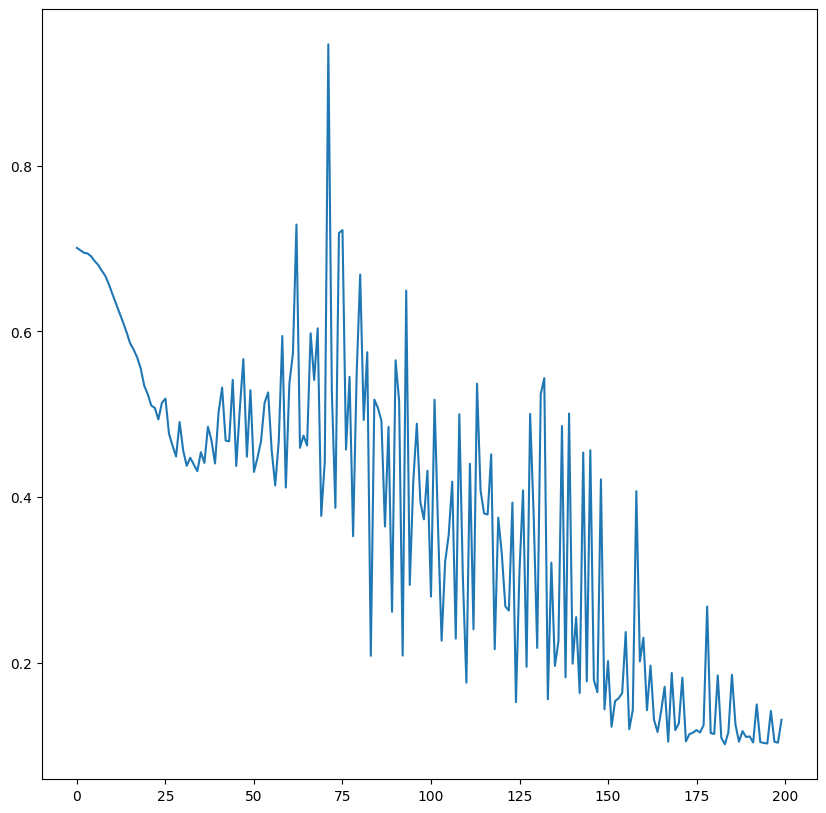

In [537]:
losses = []
num_points_per_batch = 100
num_iters = 200

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    shuffled_indices = np.random.choice(n, size=n, replace=False)
    X_shuffled = X_norm[shuffled_indices, :]
    y_shuffled = y[shuffled_indices]
    for batch_min_index in range(0, n, num_points_per_batch):
        batch_max_index = min(batch_min_index + num_points_per_batch, n)
        neural_network.train(
            X_norm[batch_min_index:batch_max_index, :],
            y[batch_min_index:batch_max_index],
            loss_function,
            lr,
            0,
        )

    losses.append(neural_network.get_average_loss(X_norm, y, loss_function))

plt.plot(losses)
print(losses[-1])

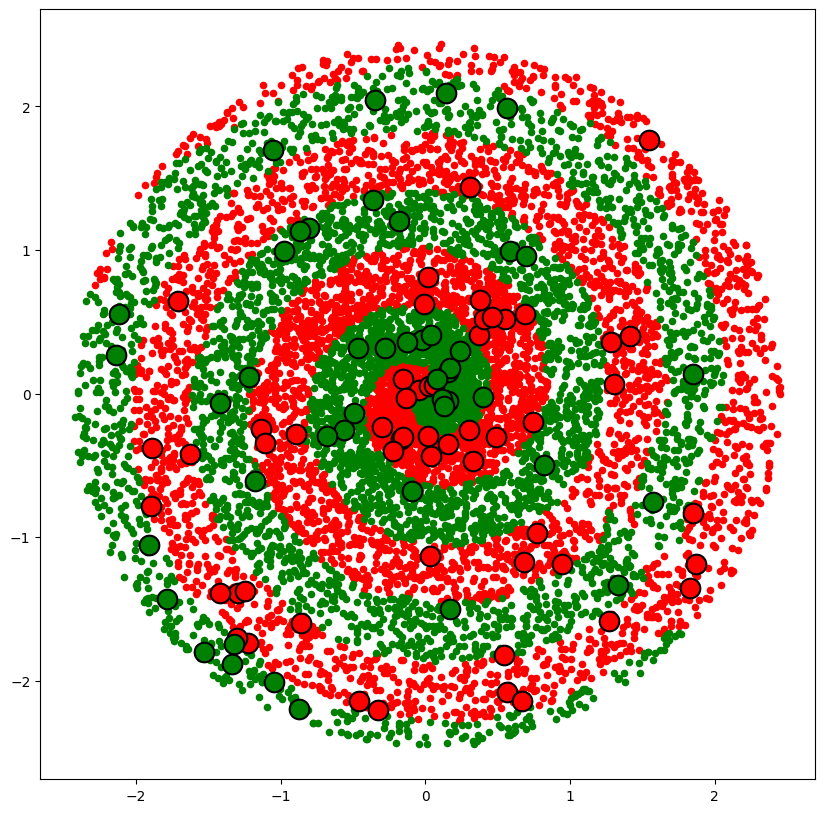

In [538]:
make_plot(neural_network, 100)

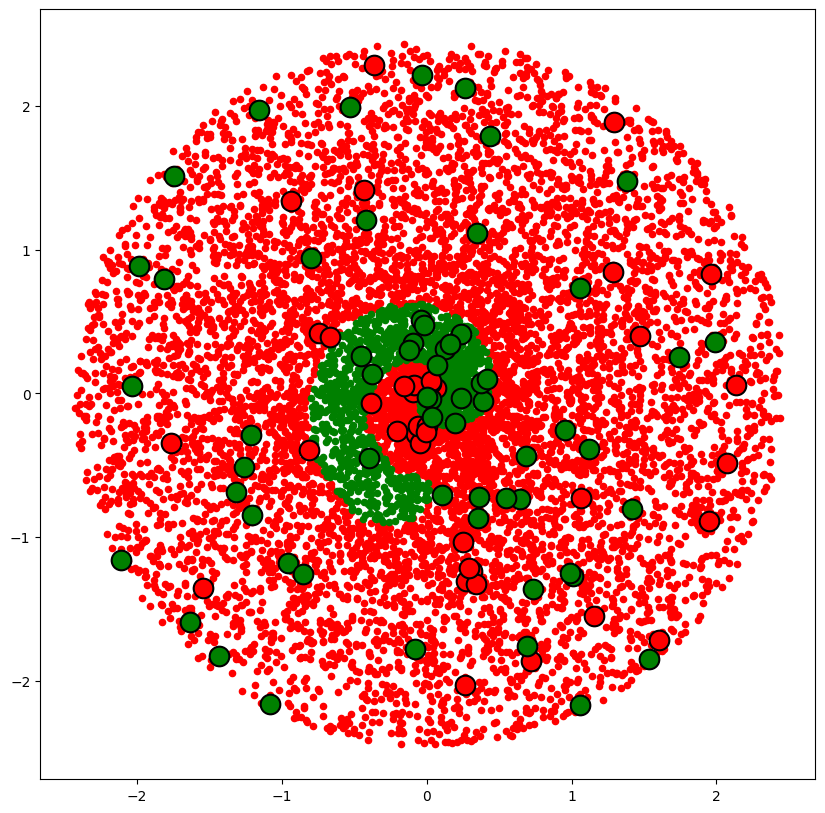

In [276]:
make_plot(neural_network, 100)

In [ ]:
for i in range(num_points):
    print(i, neural_network.run(X_norm[i, :]), y[i])

0 [0.12010215] False
1 [0.99530564] True
2 [0.03138989] False
3 [0.98665704] True
4 [0.99537226] True
5 [0.99491523] True
6 [0.00030685] False
7 [0.941103] True
8 [0.06001086] False
9 [0.01176483] False
10 [0.00446203] False
11 [0.969386] True
12 [0.91079274] True
13 [0.97520183] True
14 [0.04537237] False
15 [0.90392371] True
16 [8.87731425e-05] False
17 [0.01610622] False
18 [0.99303444] True
19 [0.99222492] True


In [ ]:
x = X[3, :]
neural_network.debug_gradients(x, y[3], loss_function)

{'inputs': array([-1.95890129, -4.1283068 ]),
 'prediction': array([0.01554382]),
 'actual': np.True_,
 'initial_output_gradient': array([-0.98445618]),
 'input_gradients_by_layer': [array([-0.00098571, -0.00321347]),
  array([ 0.        ,  0.        ,  0.00507072,  0.        ,  0.        ,
         -0.00325318, -0.00210959, -0.0022759 , -0.00255178,  0.00596124,
          0.        , -0.0011685 ,  0.        ,  0.00353362, -0.00100561,
          0.        ,  0.00045075, -0.00313603,  0.00129558, -0.00101641,
         -0.        ,  0.00110632,  0.00049715, -0.        ,  0.00254087,
         -0.0013405 , -0.        , -0.        , -0.00362074, -0.        ]),
  array([ 0.00018866,  0.00064095,  0.00507072,  0.00299373,  0.00338006,
         -0.00325318, -0.00210959, -0.0022759 , -0.00255178,  0.00596124,
          0.00163452, -0.0011685 ,  0.00254182,  0.00353362, -0.00100561,
          0.00286733,  0.00045075, -0.00313603,  0.00129558, -0.00101641,
         -0.000606  ,  0.00110632,  0.00

In [ ]:
x = X[3, :]
neural_network.debug_gradients(x, y[3], nn.SquaredErrorLoss())

{'inputs': array([-5.24099392, -9.93229213]),
 'prediction': array([0.0169147]),
 'actual': np.True_,
 'initial_output_gradient': array([-1.9661706]),
 'input_gradients_by_layer': [array([-0.00407608, -0.01122196]),
  array([-0.        , -0.        ,  0.00568117,  0.        ,  0.        ,
          0.00057402, -0.00200159, -0.00602267,  0.00128135,  0.01220926]),
  array([-0.00141985, -0.00022458,  0.00568117,  0.01094086,  0.00040158,
          0.00057402, -0.00200159, -0.00602267,  0.00128135,  0.01220926]),
  array([-0.        ,  0.        , -0.        ,  0.01449367, -0.00606749,
         -0.        ,  0.01024111,  0.        , -0.00103029,  0.00520541]),
  array([-0.00817844,  0.00940212, -0.01450343,  0.01449367, -0.00606749,
         -0.02264702,  0.01024111,  0.00585493, -0.00103029,  0.00520541]),
  array([-0.03269465])],
 'weights_gradients_by_layer': [array([[ 0.        ,  0.        ],
         [ 0.        ,  0.        ],
         [-0.02977498, -0.05642704],
         [ 0.     

In [ ]:
neural_network.layers[4].weights

array([[-1.20018167,  0.38658871,  0.43033258]])

In [ ]:
neural_network.layers[0].weights @ X[2, :]

array([28.3311688 , -2.31432276,  2.99818948])

In [ ]:
X[:3]

array([[ 4.45575744, -3.27259628],
       [-1.15536192, -0.5706189 ],
       [ 6.27744359,  9.69237472]])

In [ ]:
logger.setLevel(logging.ERROR)


def run_test(num_points, num_iterations):
    random_sample = np.random.choice(len(X), size=num_points, replace=False)

    weight_histories = [[] for l in layers]
    inputs = [[] for l in layers]
    gradients = [[] for l in layers]
    losses_by_iter = []

    for training_iteration in range(num_iterations):
        total_loss = 0
        for i in random_sample:
            loss_function = nn.SquaredErrorLoss()
            output = neural_network.run(X[i, :])
            logger.debug(f"output: {output}")
            loss = loss_function.get_loss(output, y[i])
            total_loss += loss
            logger.debug(f"loss: {loss}")
            output_gradient = loss_function.output_gradient(output, y[i])
            logger.debug(f"output_gradient: {output_gradient}")
            neural_network.update(output_gradient, learning_rate=0.1, regularization=0)
            for k, l in enumerate(neural_network.layers):
                weight_histories[k].append(copy.deepcopy(l.weights))
                inputs[k].append(copy.deepcopy(l.previous_inputs))
                gradients[k].append(copy.deepcopy(l.output_gradient))

        losses_by_iter.append(total_loss / num_points)
        logger.info(
            f"--------------------training iteration: {training_iteration}---------------------"
        )

    return {
        "average_losses": losses_by_iter,
        "weight_histories_by_layer": [
            np.concat([m[:, :, None] for m in weight_history], axis=2)
            for weight_history in [
                weight_histories[0],
                weight_histories[2],
                weight_histories[4],
            ]
        ],
        "inputs_by_layer": [
            np.concat([g[:, None] for g in layer_inputs], axis=1)
            for layer_inputs in inputs
        ],
        "gradients_by_layer": [
            np.concat([g[:, None] for g in layer_gradients], axis=1)
            for layer_gradients in gradients
        ],
    }
    #    neural_network.debug_print()

In [ ]:
test_result = run_test(10, 100)

(array([ 978.,   22.,    0.,    0.,    0.,    0., 1000.,    0.,    0.,
        1000.]),
 array([-1.44732527, -1.22465457, -1.00198388, -0.77931319, -0.55664249,
        -0.3339718 , -0.1113011 ,  0.11136959,  0.33404029,  0.55671098,
         0.77938168]),
 <BarContainer object of 10 artists>)

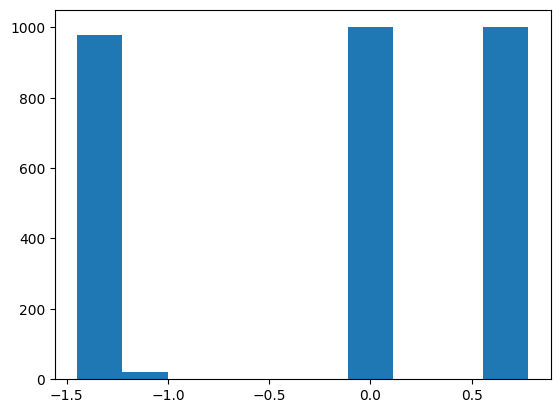

In [ ]:
plt.hist(test_result["weight_histories_by_layer"][-1].flatten())

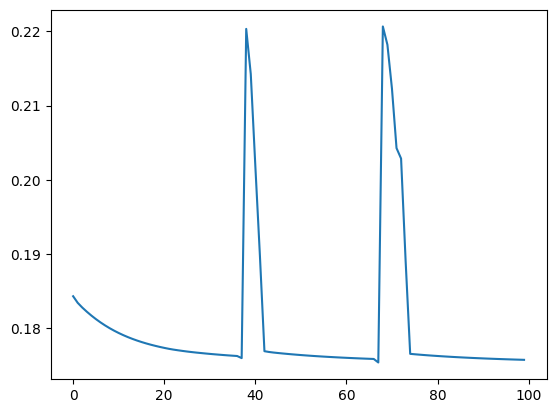

In [ ]:
plt.plot(test_result["average_losses"])

findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
findfont: score(FontEntry(fname='/home/vietafan/curling/venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUni.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/home/vietafan/curling/venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.335
findfont: score(FontEntry(fname='/home/vietafan/curling/venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
findfont: score(FontEntry(fname='/home/vietafan/curling/venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono

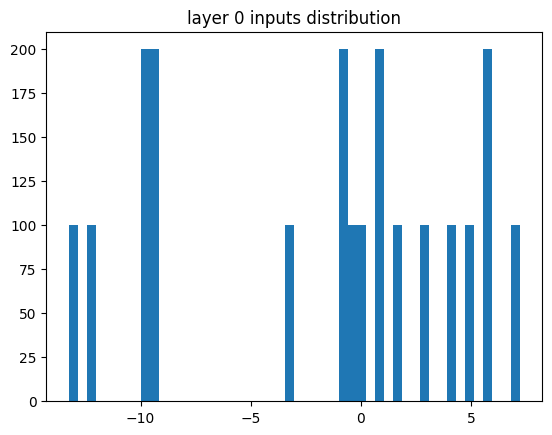

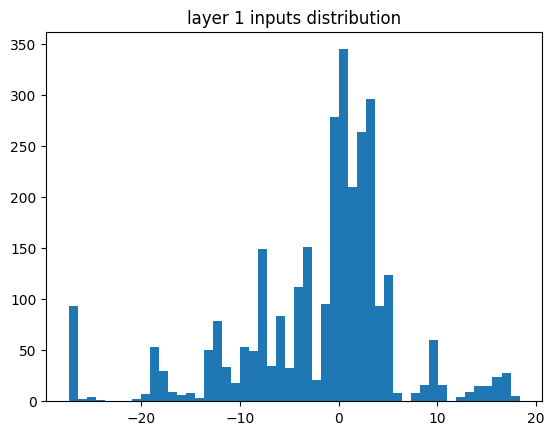

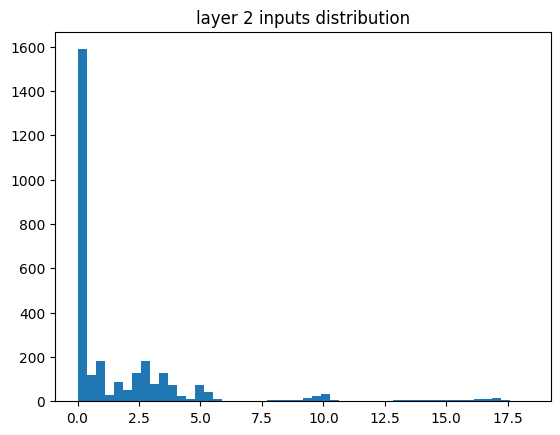

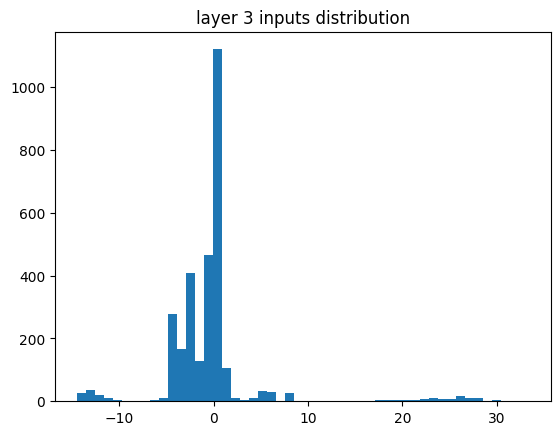

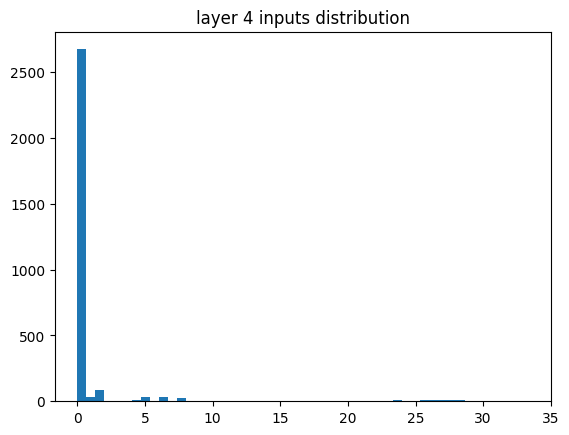

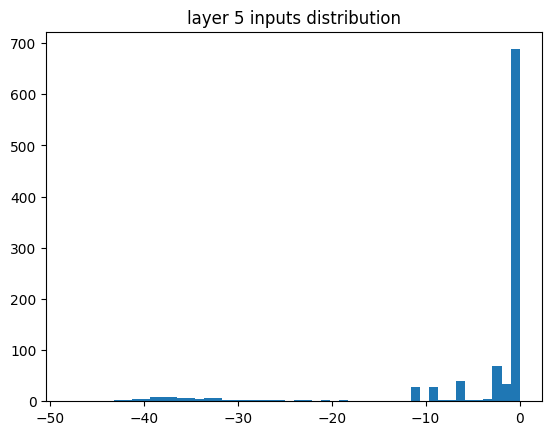

<Figure size 640x480 with 0 Axes>

In [ ]:
for k, layer in enumerate(test_result["inputs_by_layer"]):
    plt.title(f"layer {k} inputs distribution")
    plt.hist(layer.flatten(), bins=50)
    plt.figure()

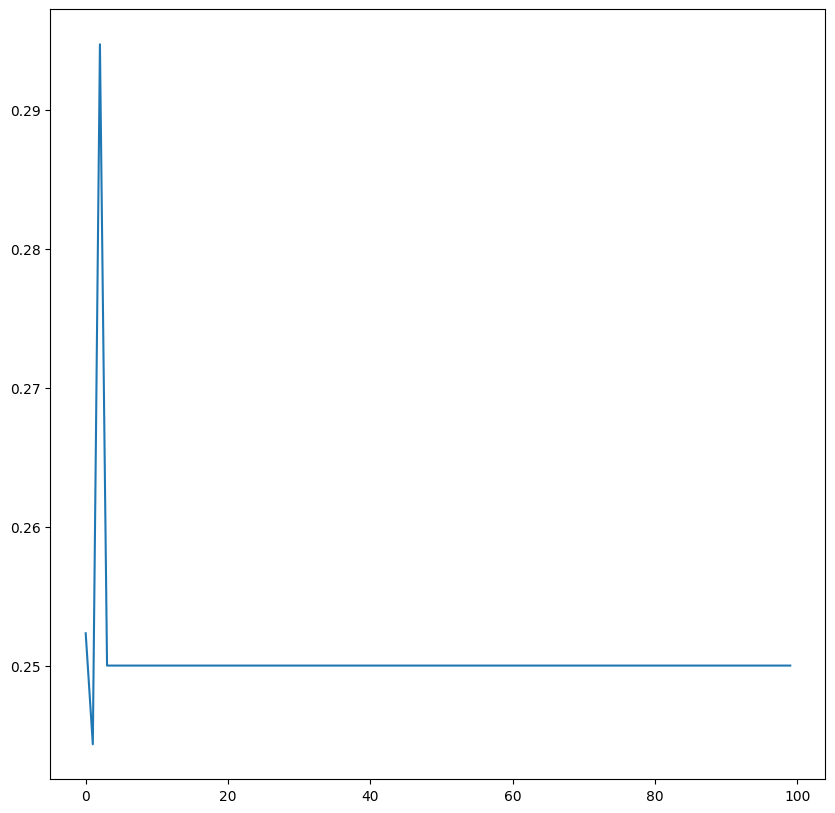

In [ ]:
test_result["gradients_by_layer"]

[[array([-0.        , -0.        ,  0.01400124]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.01326128]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.       ,  0.       , -0.0449543]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.03386851, -0.01032651]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.06735915]),
  array([-0.        , -0.        ,  0.00453226]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.00488046]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.08896485]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.01871791]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
 

In [ ]:
all_predictions

(10000,)

In [ ]:
np.concat([m[:, :, None] for m in weight_histories[0]], axis=2).reshape((6, 10))

array([[-0.24227568, -0.24227326, -0.24227084, -0.24226842, -0.24226599,
        -0.24226357, -0.24226115, -0.24225873, -0.2422563 , -0.24225388],
       [-0.07287887, -0.07287814, -0.07287742, -0.07287669, -0.07287596,
        -0.07287523, -0.0728745 , -0.07287377, -0.07287304, -0.07287231],
       [-0.51972362, -0.51971842, -0.51971322, -0.51970802, -0.51970283,
        -0.51969763, -0.51969243, -0.51968724, -0.51968204, -0.51967684],
       [ 0.94780767,  0.94779819,  0.94778871,  0.94777923,  0.94776976,
         0.94776028,  0.9477508 ,  0.94774132,  0.94773185,  0.94772237],
       [-1.03215919, -1.03214887, -1.03213855, -1.03212822, -1.0321179 ,
        -1.03210758, -1.03209726, -1.03208694, -1.03207662, -1.0320663 ],
       [-0.23251919, -0.23251686, -0.23251454, -0.23251221, -0.23250989,
        -0.23250756, -0.23250524, -0.23250291, -0.23250059, -0.23249826]])

(array([2.045e+03, 1.030e+02, 9.200e+01, 6.100e+01, 3.900e+01, 2.300e+01,
        1.100e+01, 7.000e+00, 1.000e+01, 6.000e+00, 8.000e+00, 7.000e+00,
        6.000e+00, 8.000e+00, 5.000e+00, 7.000e+00, 1.000e+00, 6.000e+00,
        6.000e+00, 4.000e+00, 7.000e+00, 4.000e+00, 2.000e+00, 8.000e+00,
        7.000e+00, 7.000e+00, 8.000e+00, 5.000e+00, 7.000e+00, 5.000e+00,
        9.000e+00, 3.000e+00, 3.000e+00, 6.000e+00, 6.000e+00, 7.000e+00,
        7.000e+00, 5.000e+00, 5.000e+00, 8.000e+00, 8.000e+00, 6.000e+00,
        7.000e+00, 7.000e+00, 1.000e+01, 9.000e+00, 3.000e+00, 1.000e+01,
        3.000e+00, 4.000e+00, 5.000e+00, 1.100e+01, 0.000e+00, 7.000e+00,
        5.000e+00, 6.000e+00, 9.000e+00, 8.000e+00, 4.000e+00, 4.000e+00,
        1.200e+01, 8.000e+00, 7.000e+00, 3.000e+00, 7.000e+00, 8.000e+00,
        5.000e+00, 1.300e+01, 5.000e+00, 6.000e+00, 7.000e+00, 9.000e+00,
        1.200e+01, 1.000e+01, 1.000e+01, 1.200e+01, 1.200e+01, 1.200e+01,
        7.000e+00, 1.500e+01, 1.700e+0

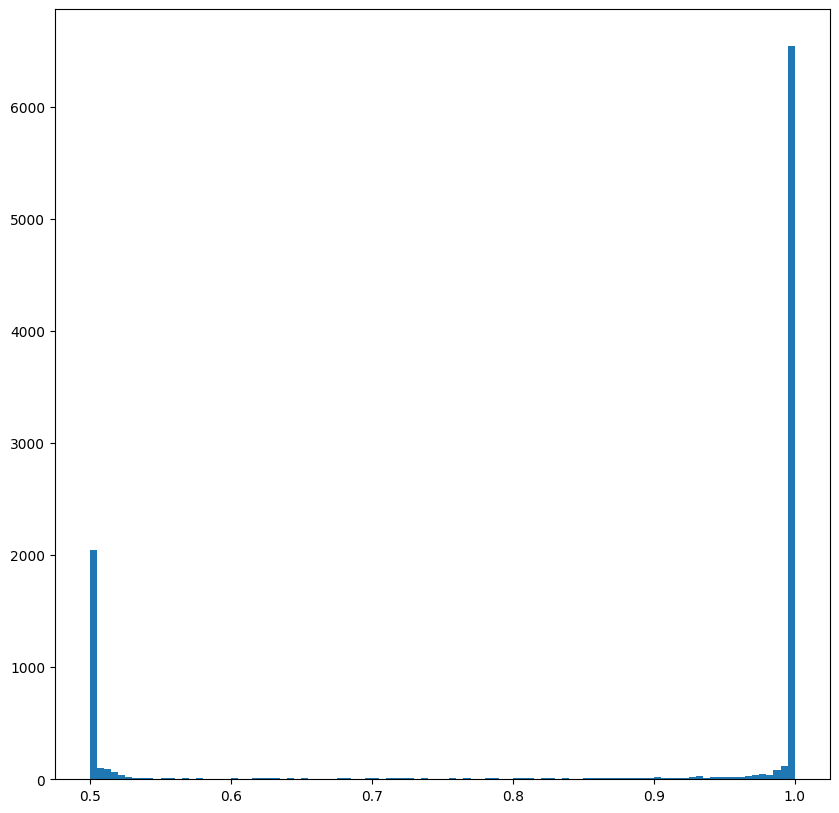

In [ ]:
plt.hist(all_float_predictions, bins=100)

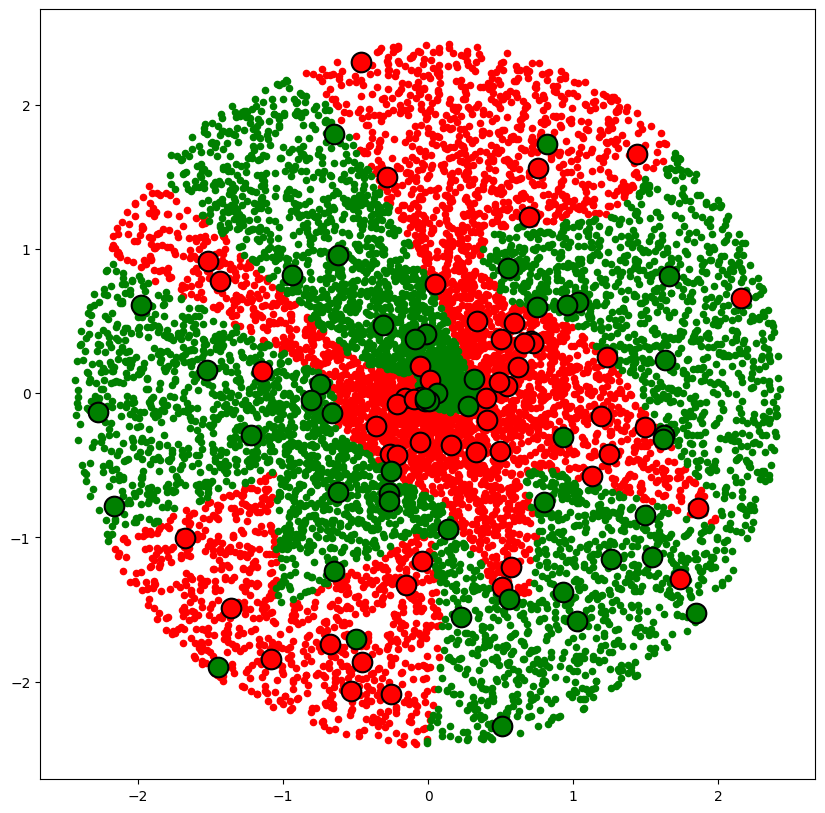

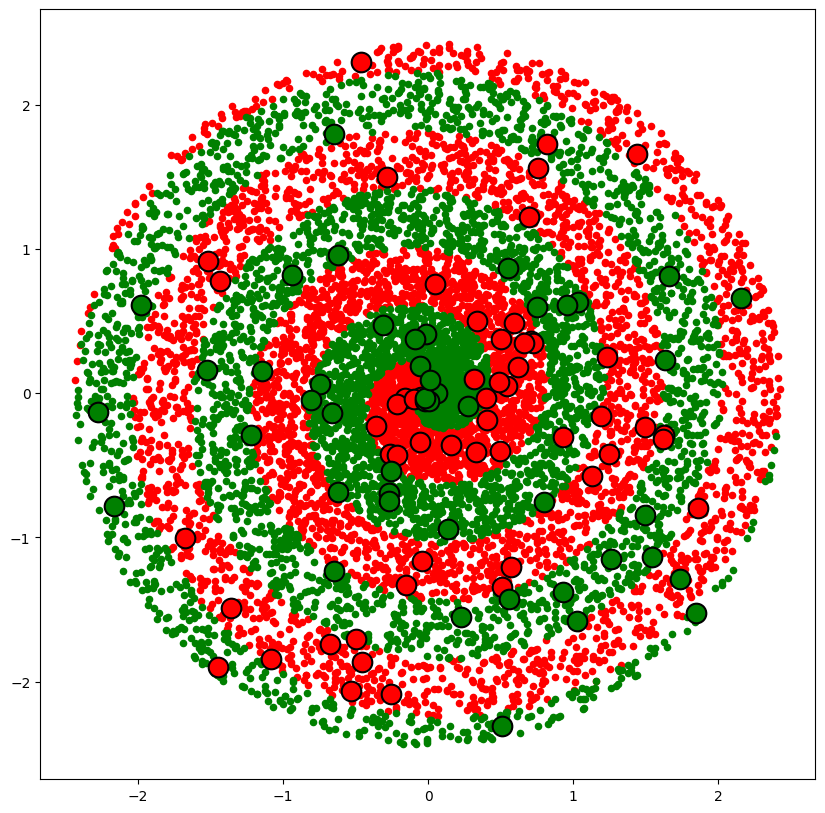

In [ ]:
sample_predictions = (
    np.array([neural_network.run(x) for x in sample_points_for_prediction]).flatten()
    > 0.5
)

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X_norm[~y, 0], X_norm[~y, 1], color="r", s=20)
plt.scatter(X_norm[y, 0], X_norm[y, 1], color="g", s=20)

plt.scatter(
    sample_points_for_prediction[~sample_predictions, 0],
    sample_points_for_prediction[~sample_predictions, 1],
    color="r",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)
plt.scatter(
    sample_points_for_prediction[sample_predictions, 0],
    sample_points_for_prediction[sample_predictions, 1],
    color="g",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)

In [ ]:
plt.rcParams["figure.figsize"] = (10, 10)
plt.scatter(X[~y, 0], X[~y, 1], color="r")
plt.scatter(X[y, 0], X[y, 1], color="g")

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
np.arange(6).reshape((3, 2))

array([[0, 1],
       [2, 3],
       [4, 5]])

In [ ]:
np.arange(1, 4).reshape((1, 3)) * (10 * np.arange(1, 3)).reshape((2, 1))

array([[10, 20, 30],
       [20, 40, 60]])